In [28]:
from matplotlib import pyplot as plt
import json
import numpy as np

In [351]:
# k-clique solution probability with graph density p
def plot_success_prob_for_var(filename, var_names, title=None, plots=["found_solution"], fig_filename=None, interpret_metric=None, interpret_solution=None, ylim=(0, 1.05),
                              relative_to_first_value=False, figsize=(7, 4), fig=None, plot_labels=None, grid=True, colors=None, alphas=None, patterns=None, yscale=None):
    with open(filename, "r") as f:
        benchmark_results = json.load(f)
    
    # print(benchmark_results)
    if fig:
        new_fig = plt.figure(fig)
    else:
        new_fig = plt.figure(figsize=figsize)
    if title:
        plt.title(title)
    w = 0.4
    num_problem_sizes = len(benchmark_results["problem_sizes"])
    main_var = np.sort(np.unique(np.array([s[var_names[0]] for s in benchmark_results["problem_sizes"]])))
    if len(var_names) > 1:
        second_var = np.array(sorted(list(set([s[var_names[1]] for s in benchmark_results["problem_sizes"]]))))
    # num_tests_sizes = iters_per_graph * benchmark_results["num_graphs"]
    # plt.xticks(np.arange(num_problem_sizes), benchmark_results["problem_sizes"])
    plt.ylabel("Success probability")
    plt.xlabel(var_names[0])
    for i, plot in enumerate(plots):
        if len(var_names) > 1:
            for sv in second_var:
                found_solutions = [sum([g[plot] for g in s]) for i,s in enumerate(benchmark_results["results_per_size"]) if benchmark_results["problem_sizes"][i][var_names[1]] == sv]
                if relative_to_first_value:
                    normalization = found_solutions[0]
                else:
                    if interpret_metric == None or interpret_metric[i] == "per_graph":
                        normalization = benchmark_results["num_graphs"]
                    elif interpret_metric[i] == "per_iter":
                        normalization = benchmark_results["num_graphs"] * np.array([ s["iters_per_graph"] for s in benchmark_results["problem_sizes"] if s[var_names[1]] == sv])
                label = f"{var_names[1]}={sv}" if plot_labels == None else plot_labels[i]
                plt.plot(main_var[:len(found_solutions)], np.array(found_solutions) / normalization, "-" if not patterns else patterns[i], label=label)
        else:
            if interpret_metric == None or interpret_metric[i] == "per_graph":
                normalization = benchmark_results["num_graphs"]
            elif interpret_metric[i] == "per_iter":
                normalization = benchmark_results["num_graphs"] * np.array([s["iters_per_graph"] for s in benchmark_results["problem_sizes"]])
            if interpret_solution == None or interpret_solution[i] == "number":
                found_solutions = [sum([g[plot] for g in s]) for s in benchmark_results["results_per_size"]]
            elif interpret_solution[i] == "not_zero":
                found_solutions = [sum([g[plot] > 0 for g in s]) for s in benchmark_results["results_per_size"]]
            label = plot if plot_labels == None else plot_labels[i]
            plt.plot(main_var[:len(found_solutions)], np.array(found_solutions) / normalization, "-" if not patterns else patterns[i],label=label, color=None if not colors else colors[i])
    # if "valid_cliques" in plots:
    #     valid_cliques = np.array([sum([g["valid_cliques"] > 0 for g in s]) for s in benchmark_results["results_per_size"]])
    #     plt.plot(main_var, np.array(valid_cliques) / benchmark_results["num_graphs"]-0.01, label=f"valid cliques")
    if grid:
        plt.grid(True, "major")
        if yscale=="log":
            plt.grid(True, "minor", color="black", alpha=0.1)
            print("minorticks")
            plt.minorticks_on()
    if ylim:
        plt.ylim(ylim)
    if yscale:
        plt.yscale(yscale)
    plt.legend()
    if fig_filename:
        plt.savefig(fig_filename)
    plt.show()
    return new_fig
# plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_p.json", ["p"], "Max-clique QAOA Solutions for different p", plots=["found_solution", "valid_cliques"])

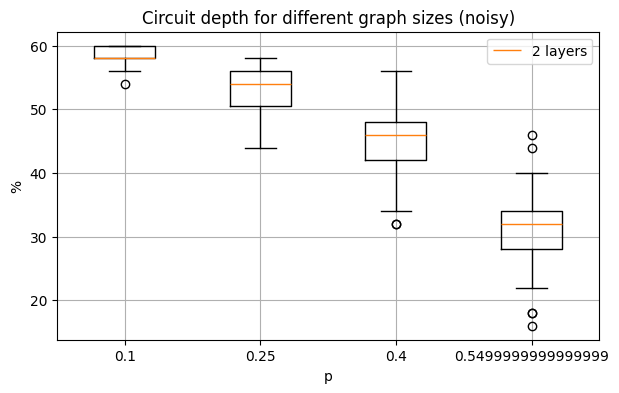

In [334]:
# k-clique solution probability with graph density p
def plot_circuit_infos(filename, var_names, title=None, plots=["depths_per_size"], fig_filename=None, ylabel="%", xlabel=None, figsize=(7, 4), plot_labels=None):
    with open(filename, "r") as f:
        benchmark_results = json.load(f)

    # print(benchmark_results)

    plt.figure(figsize=figsize)
    if title:
        plt.title(title)
    w = 0.4
    # num_problem_sizes = len(benchmark_results["problem_sizes"])
    problem_size_var = np.array([s[var_names[0]] for s in benchmark_results["problem_sizes"]])
    # num_tests_sizes = iters_per_graph * benchmark_results["num_graphs"]
    num_graphs = benchmark_results
    # plt.xticks(np.arange(num_problem_sizes), benchmark_results["problem_sizes"])
    plt.ylabel(ylabel)
    plt.xlabel(var_names[0] if xlabel==None else xlabel)
    if "depths_per_size" in plots:
        label = "2 layers" if plot_labels == None else plot_labels[0]
        depths = benchmark_results["depths_per_size"]
        plt.boxplot(depths, showfliers=True, label=label)
    plt.xticks(np.arange(1, len(problem_size_var)+1), problem_size_var)
    plt.grid()
    # plt.ylim(0, 1.05)
    plt.legend()
    if fig_filename:
        plt.savefig(fig_filename)
    plt.show()

plot_circuit_infos("benchmarkResults/qaoa_results_maxclique_p.json", ["p"], "Circuit depth for different graph sizes (noisy)", plots=["depths_per_size"])

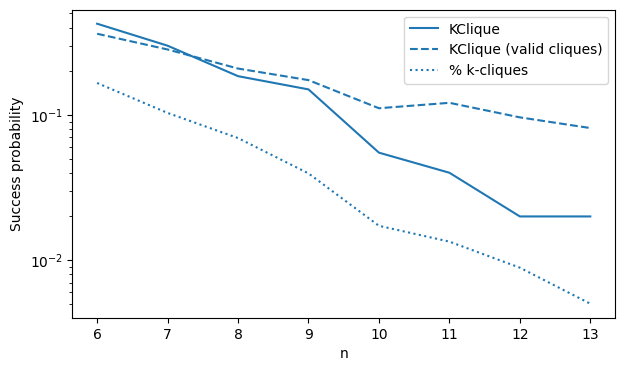

minorticks


C:\Users\Alen Leban\AppData\Local\Temp\ipykernel_32756\3889089719.py:57: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(ylim)


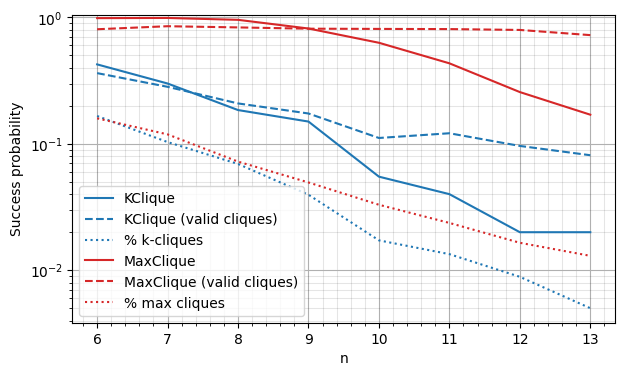

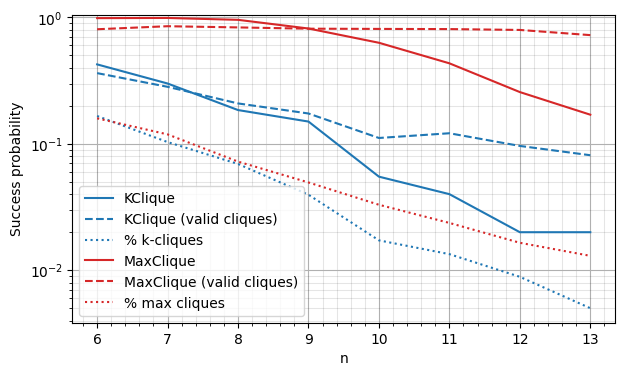

In [352]:
fig = plot_success_prob_for_var("benchmarkResults/qaoa_results_kclique_n.json", 
                          ["n"],
                          ylim=None,
                          plots=["found_solution", "valid_cliques", "k_nodes_clique_percent"],
                          plot_labels=["KClique", "KClique (valid cliques)", "% k-cliques"],
                          interpret_metric=["per_graph", "per_iter", "per_graph"],
                          fig_filename="Figures/qaoa_kclique_n", grid=False, colors=["tab:blue", "tab:blue", "tab:blue"], patterns=["-", "--", ":"], yscale="log")
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_n.json", 
                          ["n"],
                          plots=["found_solution", "valid_cliques", "k_nodes_clique_percent"],
                          plot_labels=["MaxClique", "MaxClique (valid cliques)", "% max cliques"],
                          interpret_metric=["per_graph", "per_iter", "per_graph"],
                          fig_filename="Figures/qaoa_clique_n", fig=fig, colors=["tab:red", "tab:red", "tab:red"], patterns=["-", "--", ":"], yscale="log")

minorticks


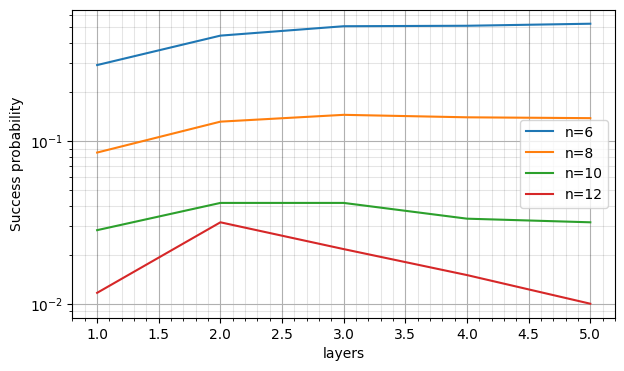

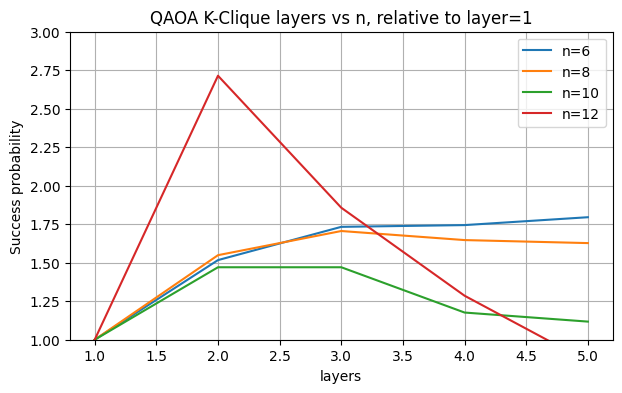

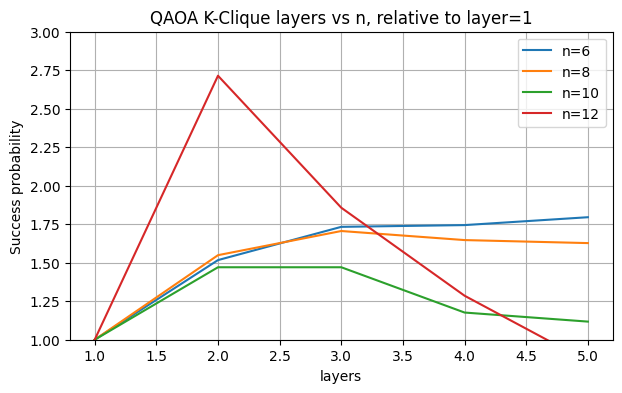

In [290]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_kclique_layers_n_temp.json", 
                          ["layers", "n"],
                        fig_filename="Figures/qaoa_kclique_layer_n", yscale="log", ylim=None)
plot_success_prob_for_var("benchmarkResults/qaoa_results_kclique_layers_n_temp.json", 
                          ["layers", "n"],
                          "QAOA K-Clique layers vs n, relative to layer=1", ylim=[1, 3], relative_to_first_value=True, fig_filename="Figures/qaoa_kclique_layer_n_relative")

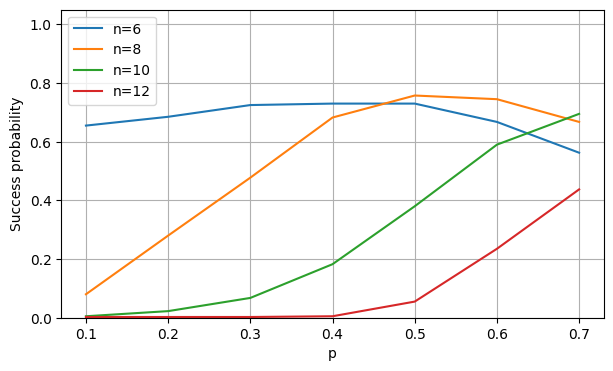

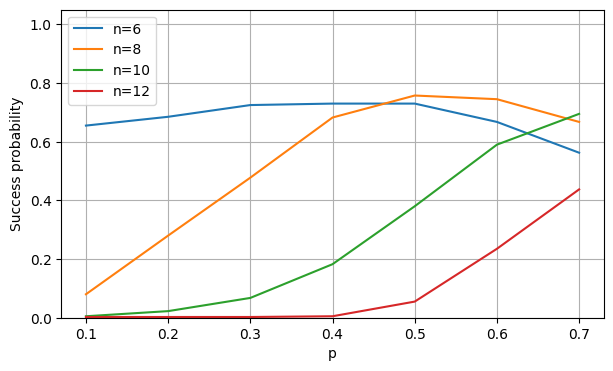

In [380]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_p_n.json", ["p", "n"], "", 
                          plots=["found_solution"],
                          fig_filename="Figures/qaoa_maxclique_p_n")
# plot_success_prob_for_var("benchmarkResults/qaoa_results_kclique_p_noisy.json", ["p"], "K-clique QAOA Solutions for different p (Noisy), k=3, n=7", 
#                           plots=["found_solution", "valid_cliques"], 
#                           fig_filename="Figures/qaoa_kclique_p_n_noisy")

In [ ]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_kclique_p.json", ["p"], "K-clique QAOA Solutions for different p, k=5, n=10", 
                          plots=["found_solution", "valid_cliques"], interpret_metric=["per_graph", "per_graph"], interpret_solution=["not_zero", "not_zero"],
                          fig_filename="Figures/qaoa_kclique_p")
plot_success_prob_for_var("benchmarkResults/qaoa_results_kclique_p_noisy.json", ["p"], "K-clique QAOA Solutions for different p (Noisy), k=3, n=7", 
                          plots=["found_solution", "valid_cliques"], 
                          fig_filename="Figures/qaoa_kclique_p_noisy")
plot_circuit_infos("benchmarkResults/qaoa_results_kclique_p.json", ["p"], "K-clique Circuit depth for different p (noisy)", plots=["depths_per_size"], fig_filename="Figures/qaoa_kclique_p_depth")
# noisy
plot_circuit_infos("benchmarkResults/qaoa_results_kclique_p_noisy.json", ["p"], "K-clique Circuit depth for different p (noisy)", plots=["depths_per_size"], fig_filename="Figures/qaoa_kclique_p_depth_noisy")

FileNotFoundError: [Errno 2] No such file or directory: 'benchmarkResults/qaoa_results_kclique_p_n.json'

[2 3 4 5 6 7 8]
[2 3 4 5 6 7 8]


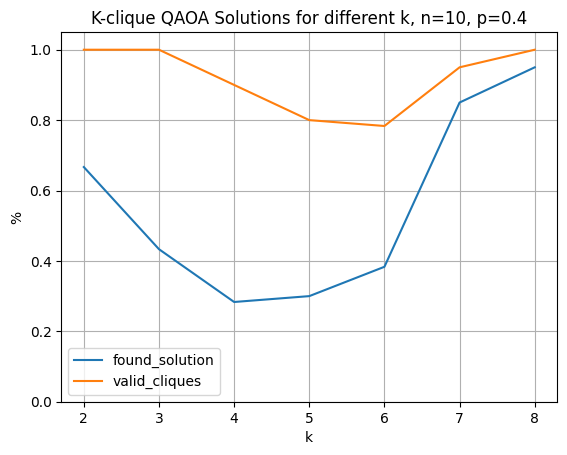

In [134]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_kclique_k.json", ["k"], "K-clique QAOA Solutions for different k, n=10, p=0.4", 
                          plots=["found_solution", "valid_cliques"], 
                          fig_filename="Figures/qaoa_kclique_k")

## MAX-Clique

[ 6  8 10 12 14 15 16]
[ 6  8 10 12 14 15 16]


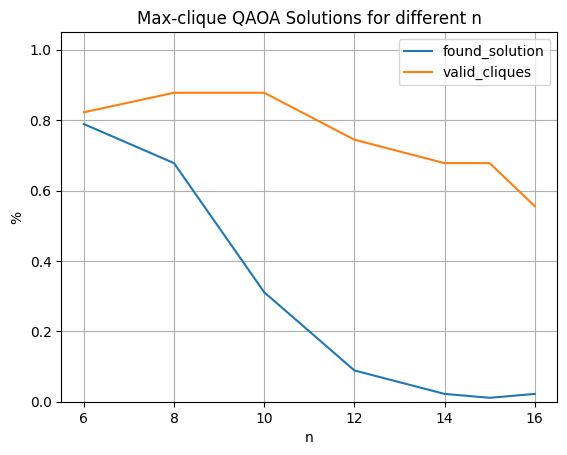

[5 7 9]
[5 7 9]


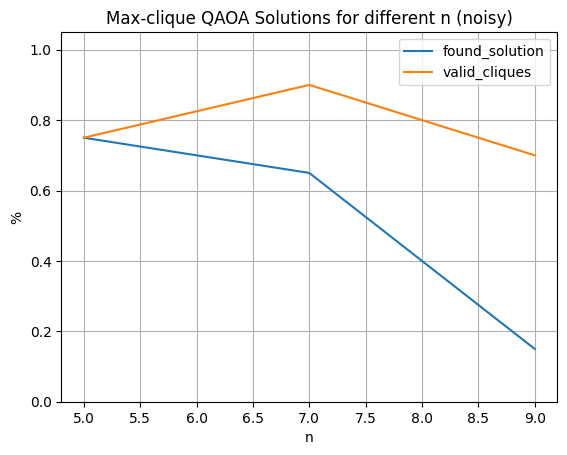

In [135]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_n_oneiter.json", ["n"], "Max-clique QAOA Solutions for different n", 
                          plots=["found_solution", "valid_cliques"], 
                          fig_filename="Figures/qaoa_maxclique_n")
# noisy optimizer
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_n_noisy.json", ["n"], "Max-clique QAOA Solutions for different n (noisy)", plots=["found_solution", "valid_cliques"], fig_filename="Figures/qaoa_maxclique_n_noisy")

[ 1  4  7 10 13 16 19]
[ 1  4  7 10 13 16 19]


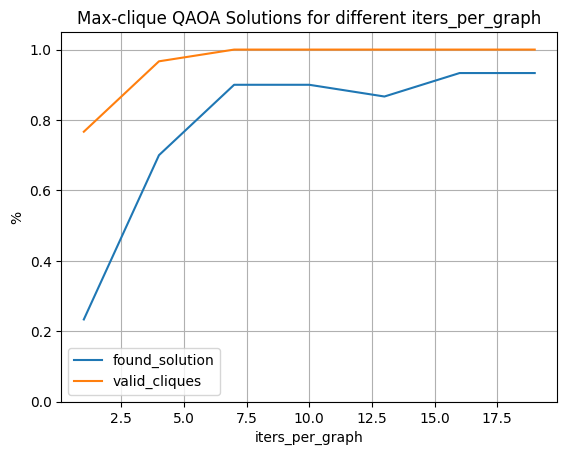

In [136]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_iters.json", ["iters_per_graph"], "Max-clique QAOA Solutions for different iters_per_graph", plots=["found_solution", "valid_cliques"], fig_filename="Figures/qaoa_maxclique_iters")

In [87]:
# # qaoa k-clique solution probability with different layers and graph sizes
# with open("benchmarkResults/qaoa_results_maxclique_layers_n.json", "r") as f:
#     benchmark_results = json.load(f)

# # valid_cliques_k_clique_sizes = [sum([g["valid_cliques"] for g in s]) for s in benchmark_results["results_per_size"]]
# # k_cliques_sizes = [sum([g["k_cliques"] for g in s]) for s in benchmark_results["results_per_size"]]
# found_solutions_per_n = []
# problem_sizes_per_n = dict()
# problem_sizes_per_n_indices = dict()
# for i, size in enumerate(benchmark_results["problem_sizes"]):
#     print(size)
#     if size["n"] not in problem_sizes_per_n:
#         problem_sizes_per_n[size["n"]] = []
#         problem_sizes_per_n_indices[size["n"]] = []
#     problem_sizes_per_n[size["n"]].append(size["layers"])
#     problem_sizes_per_n_indices[size["n"]].append(i)

# print(benchmark_results["num_graphs"])
# plt.figure()
# plt.title("Max-clique Optimal num. layers for different graph sizes")
# w = 0.4
# # plt.xticks(np.arange(num_problem_sizes), benchmark_results["problem_sizes"])
# plt.ylabel("Relative improvement")
# plt.xlabel("# layers")
# for n in problem_sizes_per_n.keys():
#     found_solutions = [sum([g["found_solution"] for g in s]) for s in [s2 for i,s2 in enumerate(benchmark_results["results_per_size"]) if i in problem_sizes_per_n_indices[n]]]
#     layers = [benchmark_results["problem_sizes"][i]["layers"] for i in problem_sizes_per_n_indices[n]]
#     print(found_solutions)
#     # print(layers)
#     # plt.plot(layers, (np.array(found_solutions) / benchmark_results["num_graphs"]) / (found_solutions[0] / benchmark_results["num_graphs"]), label=f"n={n}") # relative to layer 1
#     plt.plot(layers, (np.array(found_solutions) / benchmark_results["num_graphs"]), label=f"n={n}")
# plt.grid()
# # plt.ylim(0.7, 2)
# plt.ylim(0.0, 1.05)
# plt.legend()
# plt.show()

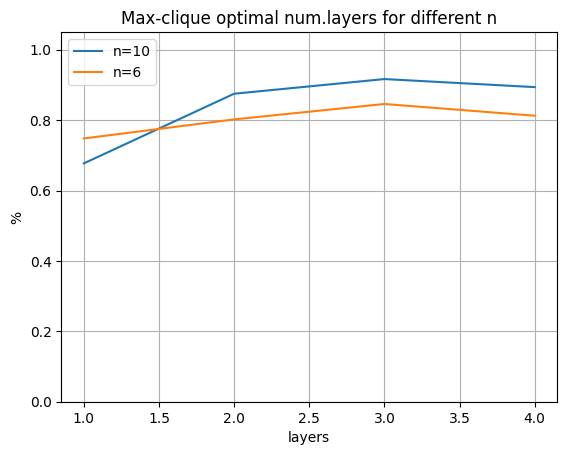

In [152]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_layers_n.json", ["layers", "n"], "Max-clique optimal num.layers for different n", fig_filename="Figures/qaoa_maxclique_layers_n")

[0.1  0.25 0.4  0.55]
[0.1  0.25 0.4  0.55]


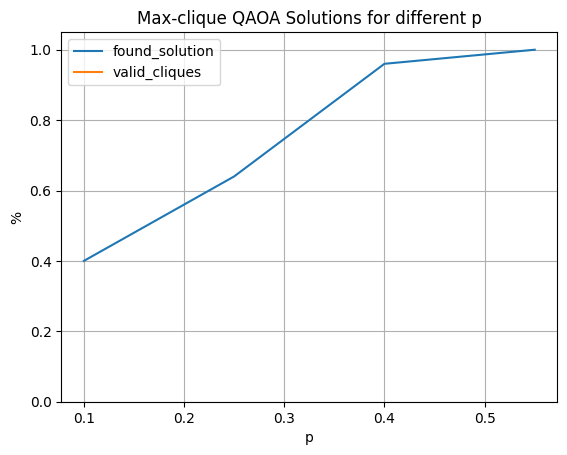

In [26]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_p.json", ["p"], "Max-clique QAOA Solutions for different p", plots=["found_solution", "valid_cliques"])

[0.1 0.3 0.5 0.7]
[0.1 0.3 0.5 0.7]


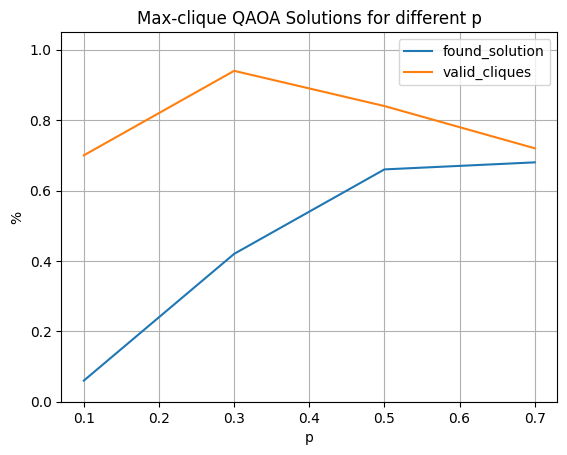

[0.1 0.3 0.5 0.7]
[0.1 0.3 0.5 0.7]


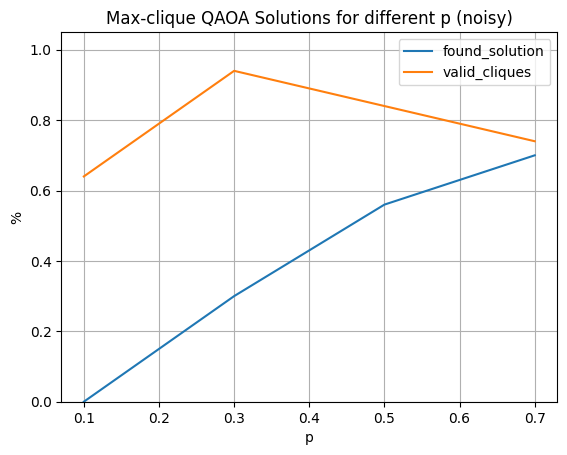

In [25]:
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_p_oneiter.json", ["p"], "Max-clique QAOA Solutions for different p", 
                          plots=["found_solution", "valid_cliques"], 
                          fig_filename="Figures/qaoa_maxclique_p")
plot_success_prob_for_var("benchmarkResults/qaoa_results_maxclique_p_oneiter_noisy.json", ["p"], "Max-clique QAOA Solutions for different p (noisy)", 
                          plots=["found_solution", "valid_cliques"], 
                          fig_filename="Figures/qaoa_maxclique_p_noisy")

## Circuit depths

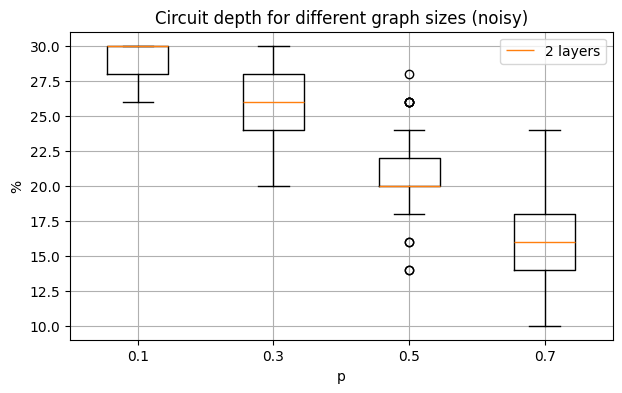

C:\Users\Alen Leban\AppData\Local\Temp\ipykernel_32756\538328483.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


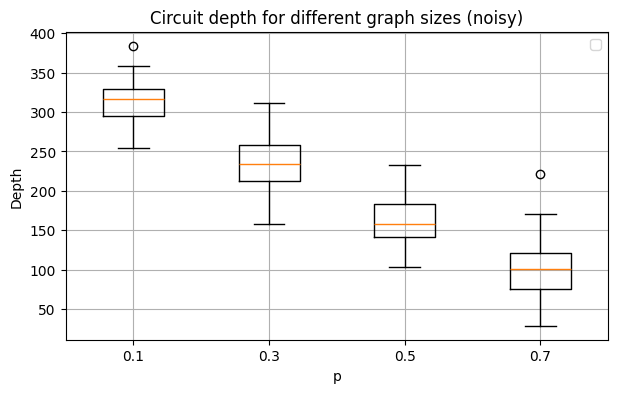

In [335]:
plot_circuit_infos("benchmarkResults/qaoa_results_maxclique_p_oneiter.json", ["p"], "Circuit depth for different graph sizes (noisy)", plots=["depths_per_size"], fig_filename="Figures/qaoa_maxclique_p_depth")
# noisy
plot_circuit_infos("benchmarkResults/qaoa_results_maxclique_p_oneiter_noisy.json", ["p"], "Circuit depth for different graph sizes (noisy)", plots=["depths_per_size"], fig_filename="Figures/qaoa_maxclique_p_depth_noisy", ylabel="Depth", plot_labels=[""])

# QA

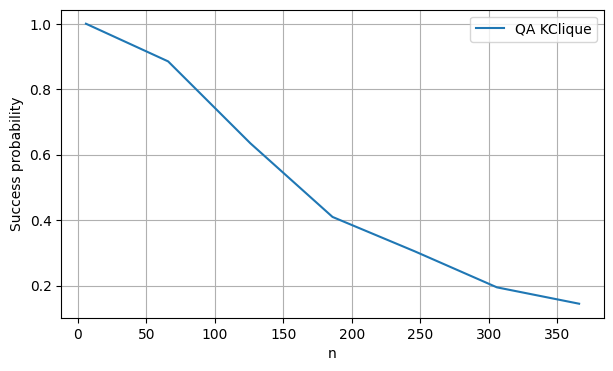

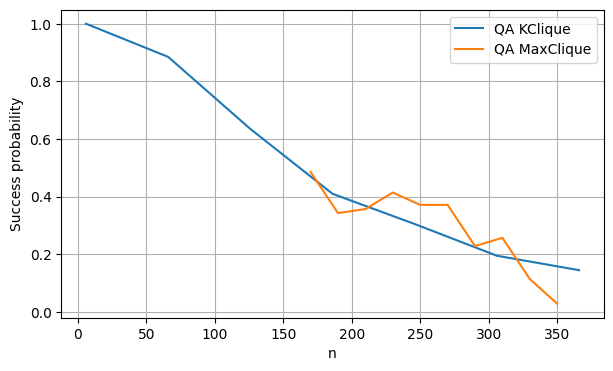

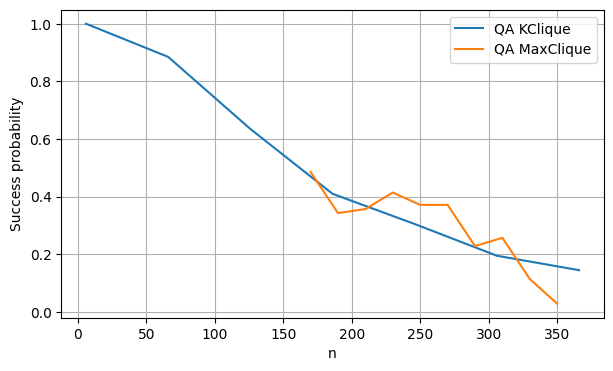

In [322]:
fig = plot_success_prob_for_var("benchmarkResults/qa_results_kclique_n.json", ["n"], 
                          plots=["found_solution"], yscale="linear", ylim=None, plot_labels=["QA KClique"])
plot_success_prob_for_var("benchmarkResults/qa_results_maxclique_n.json", ["n"], 
                          plots=["found_solution"], yscale="linear", ylim=None, plot_labels=["QA MaxClique"], fig=fig, fig_filename="Figures/qa_clique_n")


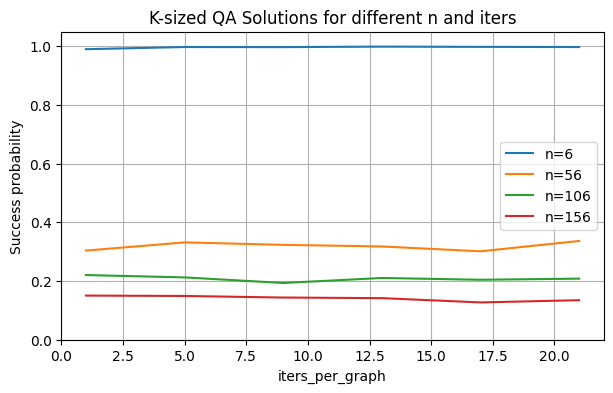

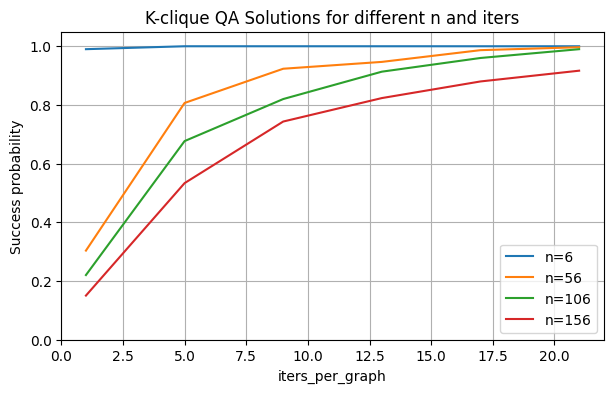

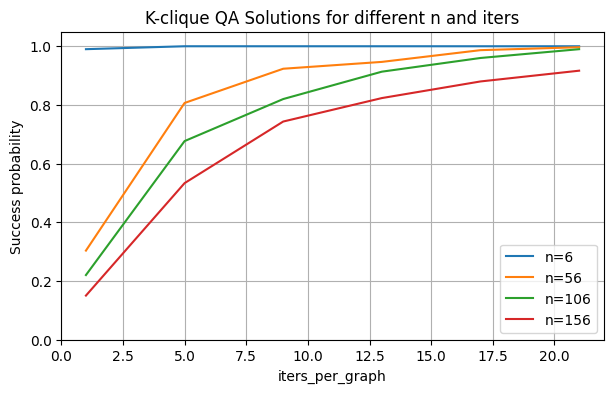

In [311]:
plot_success_prob_for_var("benchmarkResults/qa_results_kclique_iters_n.json", ["iters_per_graph", "n"], "K-sized QA Solutions for different n and iters", 
                          plots=["is_size_k"], 
                          interpret_metric=["per_iter"],
                          fig_filename="Figures/qa_kclique_ksized_iters_n")
plot_success_prob_for_var("benchmarkResults/qa_results_kclique_iters_n.json", ["iters_per_graph", "n"], "K-clique QA Solutions for different n and iters", 
                          plots=["found_solution"], 
                          interpret_metric=["per_graph"],
                          fig_filename="Figures/qa_kclique_iters_n")

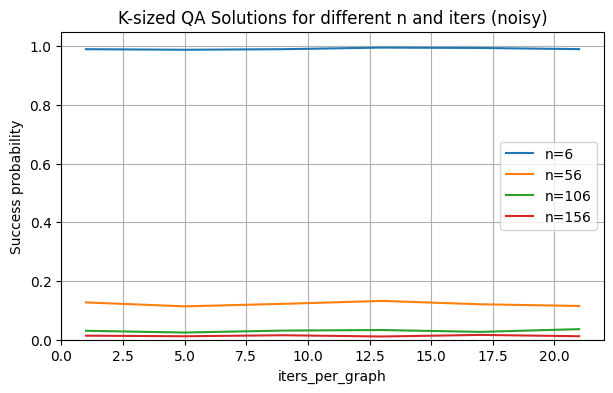

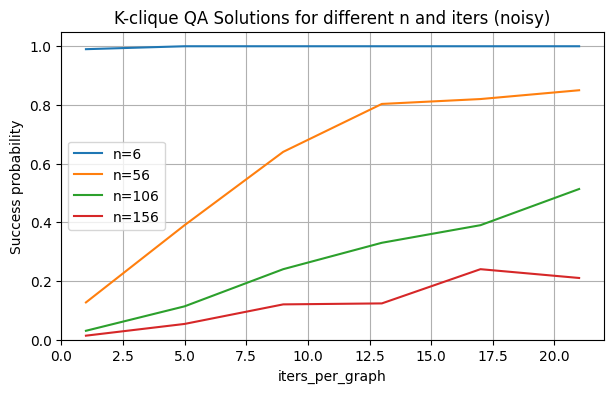

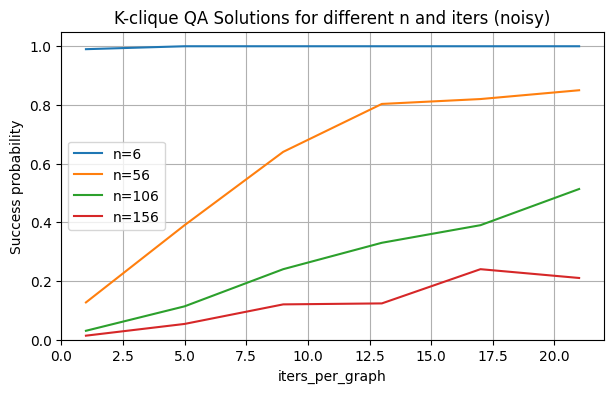

In [312]:
plot_success_prob_for_var("benchmarkResults/qa_results_kclique_iters_n_noisy.json", ["iters_per_graph", "n"], "K-sized QA Solutions for different n and iters (noisy)", 
                          plots=["is_size_k"], 
                          interpret_metric=["per_iter"], 
                          fig_filename="Figures/qa_kclique_ksized_iters_n_noisy")
plot_success_prob_for_var("benchmarkResults/qa_results_kclique_iters_n_noisy.json", ["iters_per_graph", "n"], "K-clique QA Solutions for different n and iters (noisy)", 
                          plots=["found_solution"], 
                          interpret_metric=["per_graph"],
                          fig_filename="Figures/qa_kclique_iters_n_noisy")

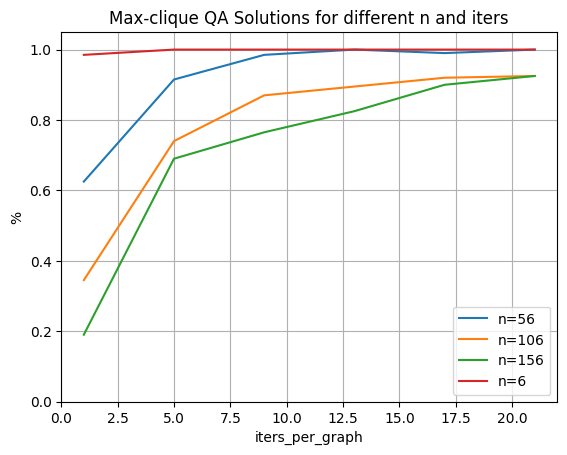

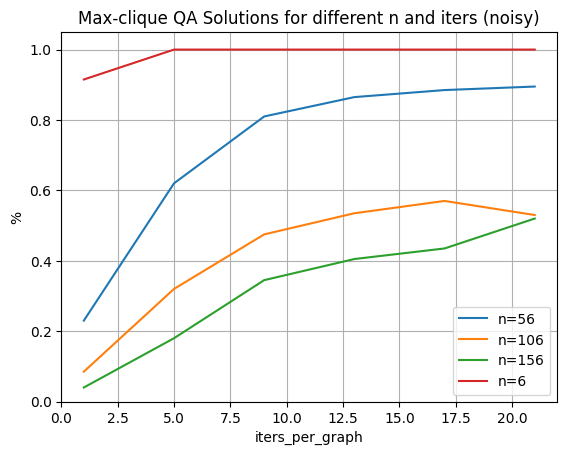

In [181]:
plot_success_prob_for_var("benchmarkResults/qa_results_maxclique_iters_n.json", ["iters_per_graph", "n"], "Max-clique QA Solutions for different n and iters", 
                          plots=["found_solution"], 
                          interpret_metric=["per_graph"], 
                          fig_filename="Figures/qa_maxclique_iters_n")
plot_success_prob_for_var("benchmarkResults/qa_results_maxclique_iters_n_noisy.json", ["iters_per_graph", "n"], "Max-clique QA Solutions for different n and iters (noisy)", 
                          plots=["found_solution"], 
                          interpret_metric=["per_graph"], 
                          fig_filename="Figures/qa_maxclique_iters_n_noisy")

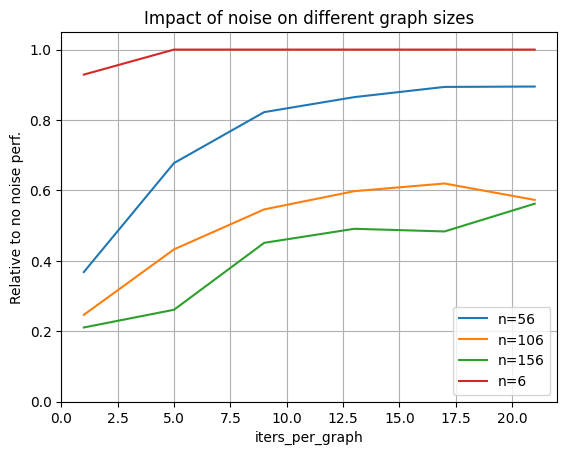

In [40]:
def plot_noise_influence(no_noise_filename, noise_filename, var_names, title, plots=["found_solutions"], interpret_metric=None, interpret_solution=None, fig_filename=None, ylabel=None):
    with open(no_noise_filename, "r") as f:
        benchmark_results = json.load(f)
    with open(noise_filename, "r") as f:
        benchmark_results_noise = json.load(f)

    # print(benchmark_results)

    plt.figure()
    if title:
        plt.title(title)
    w = 0.4
    num_problem_sizes = len(benchmark_results["problem_sizes"])
    main_var = np.unique(np.array([s[var_names[0]] for s in benchmark_results["problem_sizes"]]))
    if len(var_names) > 1:
        second_var = np.array(list(set([s[var_names[1]] for s in benchmark_results["problem_sizes"]])))
    # num_tests_sizes = iters_per_graph * benchmark_results["num_graphs"]
    # plt.xticks(np.arange(num_problem_sizes), benchmark_results["problem_sizes"])
    if ylabel:
        plt.ylabel(ylabel)
    else:
        plt.ylabel("%")
    plt.xlabel(var_names[0])
    for i, plot in enumerate(plots):
        if len(var_names) > 1:
            for sv in second_var:
                found_solutions = [sum([g[plot] for g in s]) for i,s in enumerate(benchmark_results["results_per_size"]) if benchmark_results["problem_sizes"][i][var_names[1]] == sv]
                found_solutions_noise = [sum([g[plot] for g in s]) for i,s in enumerate(benchmark_results_noise["results_per_size"]) if benchmark_results_noise["problem_sizes"][i][var_names[1]] == sv]
                # if interpret_metric == None or interpret_metric[i] == "per_graph":
                #     normalization = benchmark_results["num_graphs"]
                # elif interpret_metric[i] == "per_iter":
                #     normalization = benchmark_results["num_graphs"] * np.array([ s["iters_per_graph"] for s in benchmark_results["problem_sizes"] if s[var_names[1]] == sv])
                plt.plot(main_var, np.array(found_solutions_noise) / np.array(found_solutions), label=f"{var_names[1]}={sv}")
        else:
            if interpret_solution == None or interpret_solution[i] == "number":
                found_solutions = [sum([g[plot] for g in s]) for s in benchmark_results["results_per_size"]]
                found_solutions_noise = [sum([g[plot] for g in s]) for s in benchmark_results_noise["results_per_size"]]
            elif interpret_solution[i] == "not_zero":
                found_solutions = [sum([g[plot] > 0 for g in s]) for s in benchmark_results["results_per_size"]]
                found_solutions_noise = [sum([g[plot] > 0 for g in s]) for s in benchmark_results_noise["results_per_size"]]
            plt.plot(main_var, np.array(found_solutions_noise) / np.array(found_solutions), label=plot)
    # if "valid_cliques" in plots:
    #     valid_cliques = np.array([sum([g["valid_cliques"] > 0 for g in s]) for s in benchmark_results["results_per_size"]])
    #     plt.plot(main_var, np.array(valid_cliques) / benchmark_results["num_graphs"]-0.01, label=f"valid cliques")
    plt.grid()
    plt.ylim(0, 1.05)
    plt.legend()
    if fig_filename:
        plt.savefig(fig_filename)
    plt.show()

plot_noise_influence("benchmarkResults/qa_results_maxclique_iters_n.json", "benchmarkResults/qa_results_maxclique_iters_n_noisy.json",
                     ["iters_per_graph", "n"], "Impact of noise on different graph sizes", ["found_solution"],
                     fig_filename="Figures/qa_maxclique_iters_n_relativeNoise", ylabel="Relative to no noise perf.")